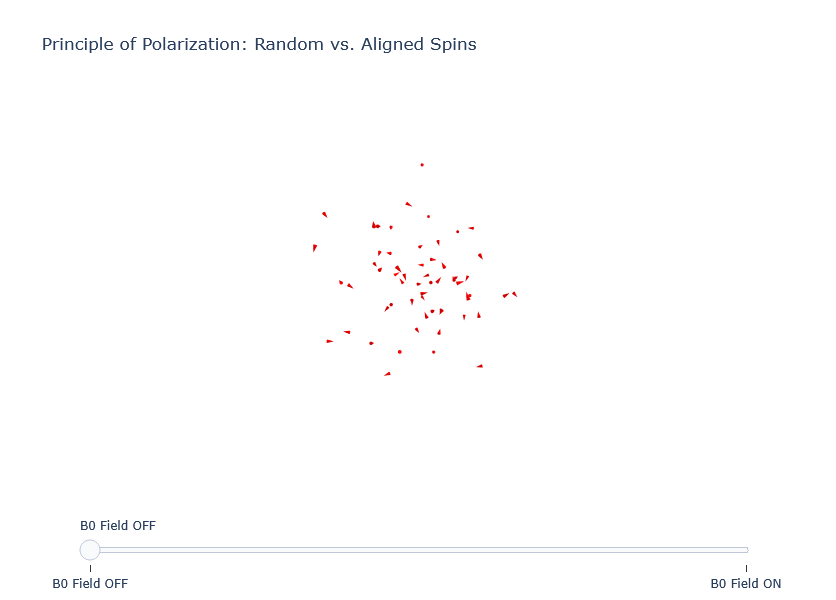

In [4]:
#| label: fig1

import numpy as np
import plotly.graph_objects as go

# 1. Setup
n_spins = 60 # Reduced number of spins for better visibility
np.random.seed(42)

# Random positions for the protons in a 3D sphere
phi_pos = np.random.uniform(0, 2*np.pi, n_spins)
costheta_pos = np.random.uniform(-1, 1, n_spins)
theta_pos = np.arccos(costheta_pos)
r = np.random.uniform(0.2, 1, n_spins)

x_pos = r * np.sin(theta_pos) * np.cos(phi_pos)
y_pos = r * np.sin(theta_pos) * np.sin(phi_pos)
z_pos = r * np.cos(theta_pos)

# 2. State OFF (0 Tesla - Random orientation)
u_0 = np.random.uniform(-1, 1, n_spins)
v_0 = np.random.uniform(-1, 1, n_spins)
w_0 = np.random.uniform(-1, 1, n_spins)
norms_0 = np.sqrt(u_0**2 + v_0**2 + w_0**2)
u_0, v_0, w_0 = u_0/norms_0, v_0/norms_0, w_0/norms_0

# 3. Create Frames for Animation
states = ["B0 Field OFF", "B0 Field ON"]
frames = []
steps = []

for state in states:
    if state == "B0 Field OFF":
        u, v, w = u_0, v_0, w_0
        net_z = 0
    else:
        # Exaggerated ratio: 60% parallel (up), 40% anti-parallel (down) for visual clarity
        n_up = int(n_spins * 0.6)
        
        u = np.zeros(n_spins)
        v = np.zeros(n_spins)
        w = np.array([1.0]*n_up + [-1.0]*(n_spins - n_up))
        
        # Shuffle to distribute randomly in space
        np.random.shuffle(w)
        
        # Small random wobble to simulate thermal energy (not perfectly straight)
        wobble = 0.15
        u = np.random.uniform(-wobble, wobble, n_spins)
        v = np.random.uniform(-wobble, wobble, n_spins)
        norms = np.sqrt(u**2 + v**2 + w**2)
        u, v, w = u/norms, v/norms, w/norms
        
        # Calculate actual net vector (sum of Z components, scaled for visibility)
        net_z = np.sum(w) / (n_spins * 0.15) 
        
    # Trace for individual protons (increased sizeref for larger arrows)
    protons = go.Cone(
        x=x_pos, y=y_pos, z=z_pos,
        u=u, v=v, w=w,
        sizemode="absolute", sizeref=0.25, 
        colorscale=[[0, 'blue'], [0.5, 'gray'], [1, 'red']], # Blue=Down, Red=Up
        cmin=-1, cmax=1,
        showscale=False,
        name="Individual Protons"
    )
    
    # Trace for Net Magnetization (Large distinct central arrow)
    net_vector = go.Cone(
        x=[0], y=[0], z=[0],
        u=[0], v=[0], w=[net_z],
        sizemode="absolute", sizeref=1.2, 
        colorscale=[[0, 'gold'], [1, 'gold']],
        showscale=False,
        name="Net Magnetization"
    )
    
    frames.append(go.Frame(data=[protons, net_vector], name=state))
    
    steps.append(dict(
        method="animate",
        args=[[state], {"mode": "immediate", "frame": {"duration": 800, "redraw": True}, "transition": {"duration": 500}}],
        label=state
    ))

# 4. Layout
fig = go.Figure(data=frames[0].data, frames=frames)

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode='cube'
    ),
    sliders=[dict(active=0, currentvalue={"prefix": ""}, pad={"t": 50}, steps=steps)],
    height=600,
    title="Principle of Polarization: Random vs. Aligned Spins"
)

fig